In [1]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.linear_model import Ridge
import tensorflow as tf
from tensorflow import keras
from keras.regularizers import l2
from keras.callbacks import EarlyStopping
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from functions import loadData, expand_mean, CAMELSrun, visualization, backtest, standardtest, print_model_weights_and_biases, permutation_importance

In [2]:
def createModel(x_shape, y_shape):
    model = keras.Sequential([
        Dense(32, activation='relu', input_shape=(x_shape,), kernel_regularizer='l2'),
        Dropout(0.1),
        Dense(16, activation='relu', kernel_regularizer='l2'),
        Dropout(0.1),
        Dense(1)
    ])


    model.compile(optimizer='adam',
                loss='mean_squared_error',
                metrics=['mean_squared_error'])


    # Summary to see the architecture
    model.summary()
    return model

In [3]:
df, X, Y = CAMELSrun('04045500', 3, 7, 'Flow+1', True)

print(X.shape[0])

c:\Users\abdul\Documents\FloodLearning\functions.py:23: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df1 = pd.read_csv(f'{flow}', delim_whitespace=True, header=None)
c:\Users\abdul\Documents\FloodLearning\functions.py:27: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df2 = pd.read_csv(f'{meta}', skiprows=3, delim_whitespace=True)


34


In [4]:
model = createModel(X.shape[0], 1)

c:\Users\abdul\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,665 (6.50 KB)

 Trainable params: 1,665 (6.50 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
predictions, datetime1 = backtest(df, model, 20, X, Y, 540, 60, None)
y_pred = predictions["prediction"]
y_test = predictions["actual"]

y_pred = np.maximum(y_pred, 0)  # Ensure no negative predictions
y_pred = np.minimum(y_pred, np.max(y_test) * 1.1)  # Cap predictions at 10% above max value of y_test

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 1.5741 - mean_squared_error: 1.0288 - val_loss: 0.7051 - val_mean_squared_error: 0.1654
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.0089 - mean_squared_error: 0.4712 - val_loss: 0.6442 - val_mean_squared_error: 0.1131
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.8734 - mean_squared_error: 0.3448 - val_loss: 0.5938 - val_mean_squared_error: 0.0730
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.8363 - mean_squared_error: 0.3181 - val_loss: 0.5761 - val_mean_squared_error: 0.0662
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7684 - mean_squared_error: 0.2611 - val_loss: 0.5959 - val_mean_squared_error: 0.0965
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7754 - mean_squared_error: 0.2785 - val_loss: 0.5702 - val_mean_squared_error: 0.0812
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6450 - mean_squared_error: 0.1586 - val_loss: 0.5616 - val_mean

MAE: 71.0 m3/s
MSE: 20615.04 m3/s
RMSE: 143.58 m3/s
MAPE: 0.12%
Accuracy: 99.883%
R2: 0.9709


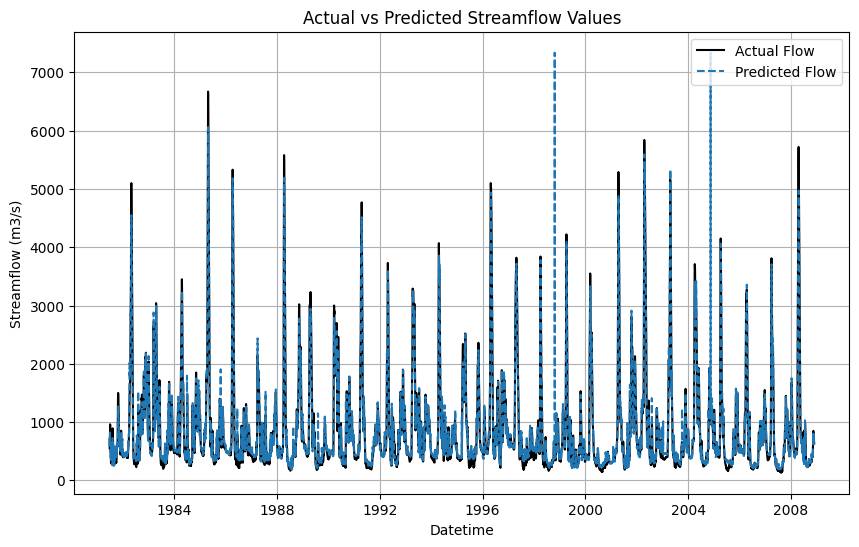

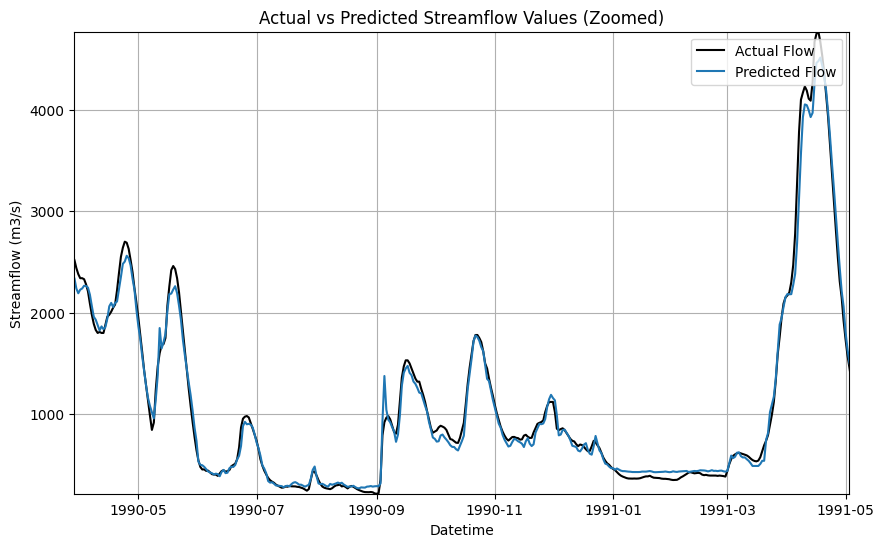

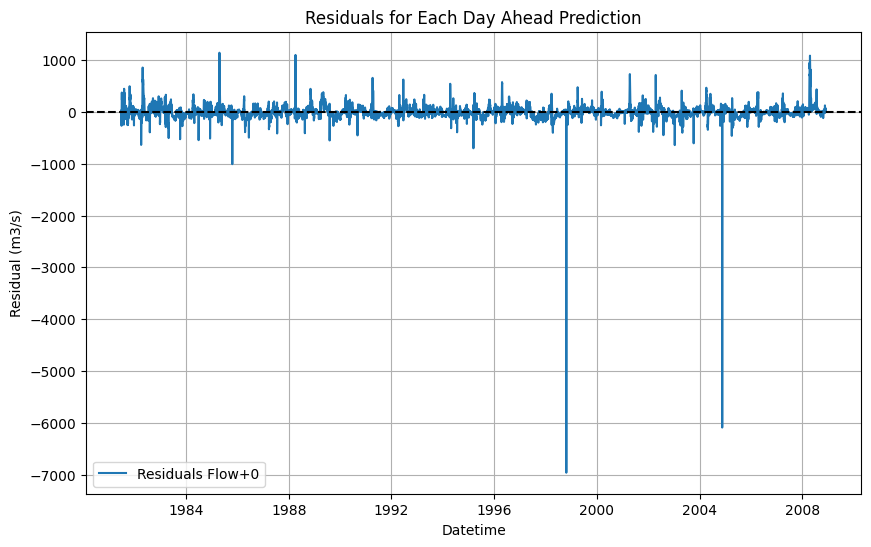

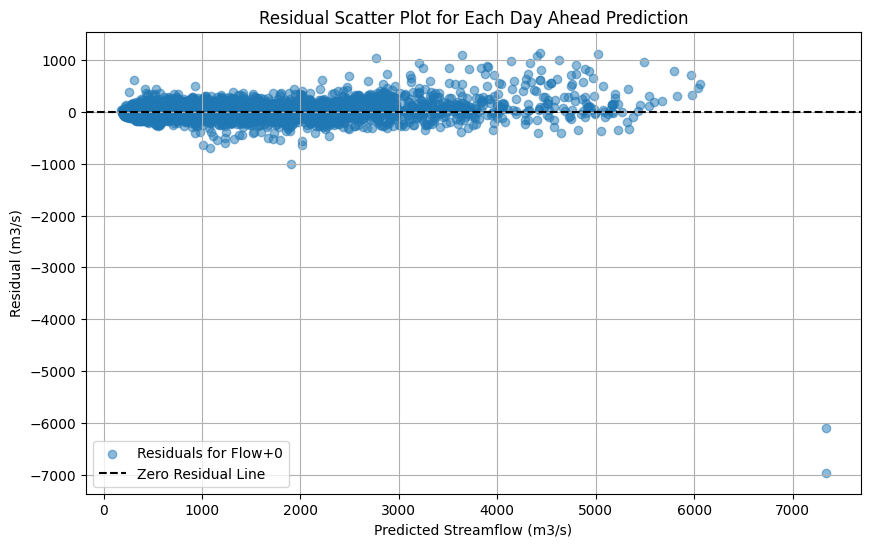

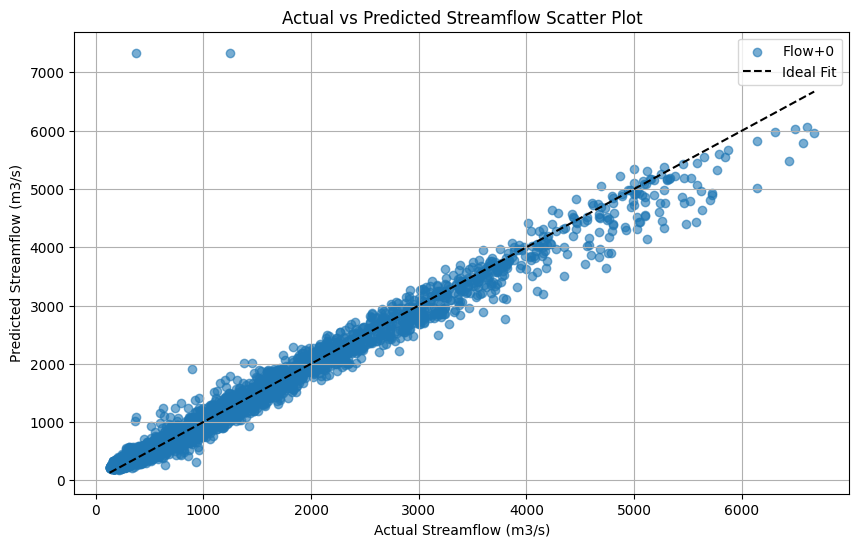

Layer 1: dense
  Weights shape: (34, 32)
  Weights: [[-4.34498712e-02 -4.52952161e-02 -3.94289121e-02 ...  1.16576768e-01
  -4.28142138e-02  1.20453395e-01]
 [-2.44887220e-03  3.32932267e-03  9.94623173e-03 ... -7.13930978e-03
   3.47211654e-03 -1.86170377e-02]
 [ 3.07836523e-03  6.11173175e-03 -7.44971400e-03 ...  1.00314466e-03
   6.18089177e-03 -6.33789785e-03]
 ...
 [ 5.08790975e-03  1.06001811e-04 -1.50897717e-02 ... -8.44817050e-03
   1.52580068e-03 -1.09464880e-02]
 [ 6.25858642e-03  4.86087846e-03 -1.30112292e-02 ... -8.28424655e-03
   5.58166765e-03 -1.20084044e-02]
 [ 4.98901354e-03 -1.27258105e-03 -1.46799842e-02 ... -4.83166426e-04
  -2.87459232e-04 -6.53162831e-03]]
  Biases shape: (32,)
  Biases: [ 0.07219183  0.19018802  0.17275383  0.14901076  0.14441344  0.00844737
 -0.04841929 -0.11787667  0.13334452  0.14737442  0.10664069 -0.08065566
  0.2083453  -0.06678894 -0.06332912  0.12477765 -0.20064549  0.184288
 -0.01621002  0.14617102  0.18519029  0.16301712  0.01930822 -0

In [6]:
visualization(datetime1, y_pred, y_test, 3200,3600)
print_model_weights_and_biases(model)

In [7]:
df, X, Y = CAMELSrun('13340000', 3, 7, 'Flow+1', False)

c:\Users\abdul\Documents\FloodLearning\functions.py:23: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df1 = pd.read_csv(f'{flow}', delim_whitespace=True, header=None)
c:\Users\abdul\Documents\FloodLearning\functions.py:27: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df2 = pd.read_csv(f'{meta}', skiprows=3, delim_whitespace=True)


In [8]:
predictions1, datetime2 = backtest(df, model, 15, X, Y, 365, 60, None)

y_pred1 = predictions1["prediction"]
y_test1 = predictions1["actual"]

y_pred1 = np.maximum(y_pred1, 0)  # Ensure no negative predictions1
y_pred1 = np.minimum(y_pred1, np.max(y_test1) * 1.1)  # Cap predictions1 at 10% above max value of y_test

Epoch 1/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0695 - mean_squared_error: 0.0608 - val_loss: 0.1397 - val_mean_squared_error: 0.1309
Epoch 2/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0474 - mean_squared_error: 0.0387 - val_loss: 0.1334 - val_mean_squared_error: 0.1248
Epoch 3/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0602 - mean_squared_error: 0.0517 - val_loss: 0.1186 - val_mean_squared_error: 0.1097
Epoch 4/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0432 - mean_squared_error: 0.0342 - val_loss: 0.1254 - val_mean_squared_error: 0.1165
Epoch 5/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0454 - mean_squared_error: 0.0365 - val_loss: 0.1174 - val_mean_squared_error: 0.1085
Epoch 6/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0548 - mean_squared_error: 0.0459 - val_loss: 0.1016 - val_mean_squared_error: 0.0928
Epoch 7/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0550 - mean_squared_error: 0.0461 - val_loss: 0.1625 - va

MAE: 1111.37 m3/s
MSE: 4370195.69 m3/s
RMSE: 2090.5 m3/s
MAPE: 0.22%
Accuracy: 99.783%
R2: 0.9582


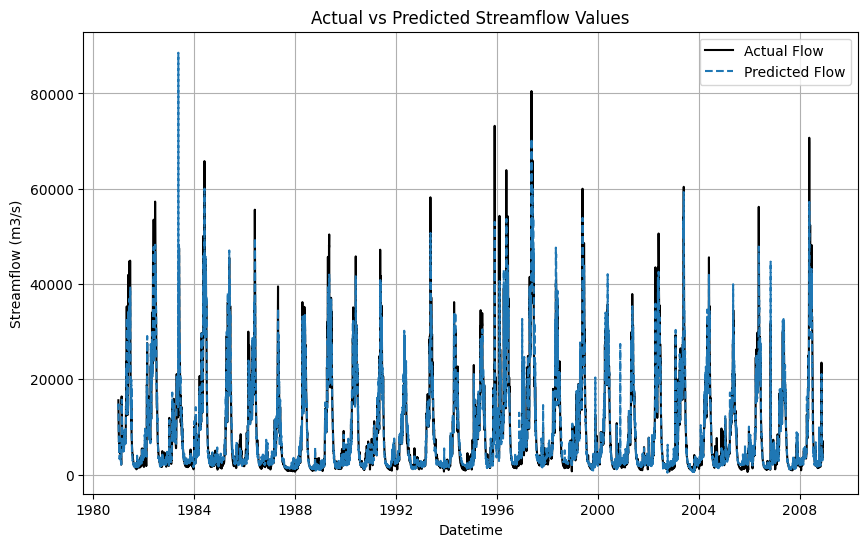

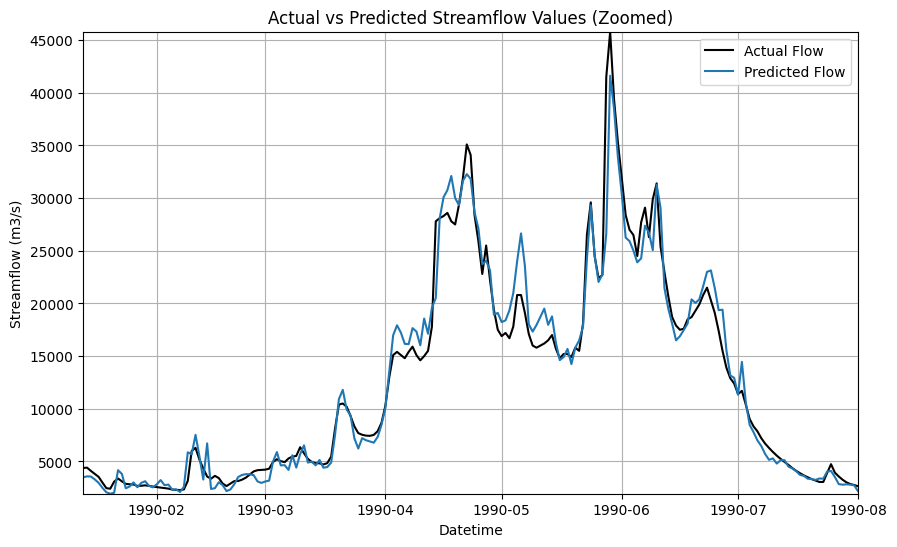

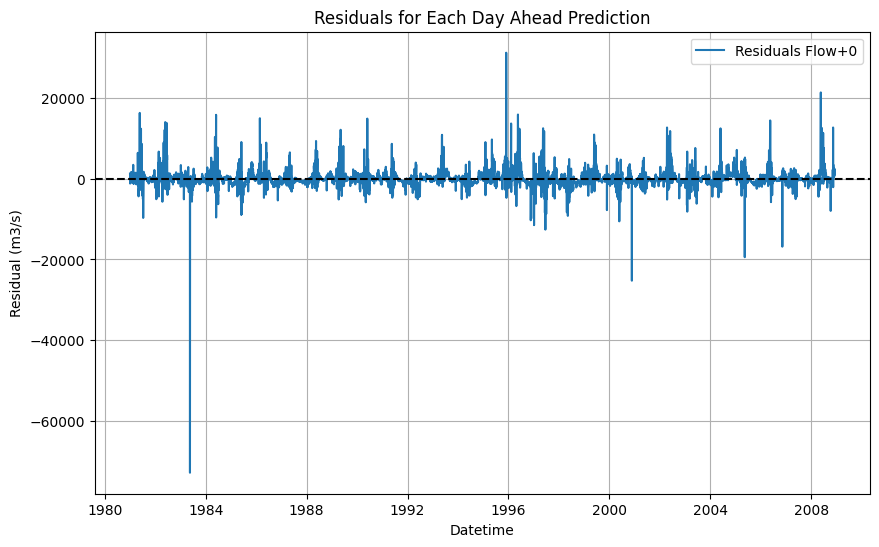

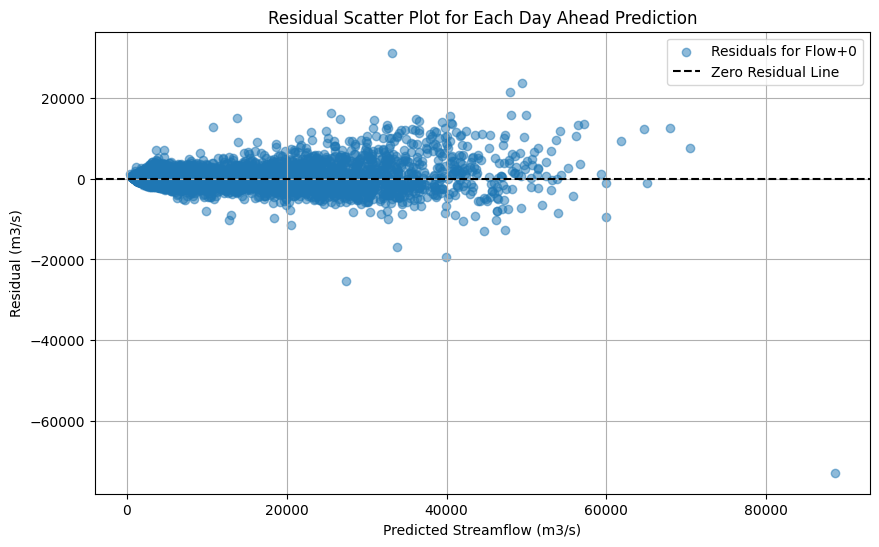

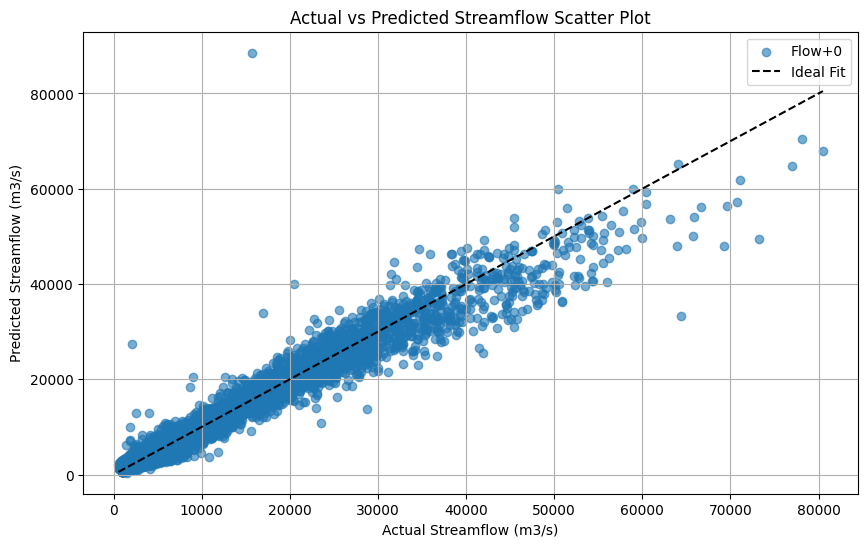

Layer 1: dense
  Weights shape: (34, 32)
  Weights: [[-0.003499   -0.04060342 -0.04295977 ...  0.08916024 -0.0605003
   0.07651003]
 [ 0.01000058  0.01548417  0.00746659 ... -0.01072601  0.00497161
  -0.0217999 ]
 [-0.04255517 -0.0371624  -0.02395718 ...  0.07584221 -0.01297216
   0.07101093]
 ...
 [-0.01281115  0.00783353  0.00856029 ... -0.0146283   0.00209764
  -0.02101543]
 [-0.00724979  0.00725938  0.00461428 ... -0.01194612  0.00201223
  -0.02722475]
 [-0.01276535  0.00694467  0.0069727  ... -0.01542551 -0.00021807
  -0.02721949]]
  Biases shape: (32,)
  Biases: [ 0.07569819  0.3047262   0.2906808   0.14951178  0.15810713  0.09894577
 -0.13173181 -0.21334927  0.29148898  0.12913387  0.02717329 -0.17305733
  0.32387638 -0.06678894 -0.02488613  0.13888288 -0.255618    0.3050269
  0.02390332  0.13799903  0.30313486  0.25310507 -0.07719404  0.12463723
  0.16052535 -0.04260971  0.31286296  0.03859509 -0.37378585 -0.14959228
  0.2986994  -0.26758   ]
Layer 2: dropout
  No weights/biase

In [9]:
visualization(datetime2, y_pred1, y_test1, 3300, 3500)
print_model_weights_and_biases(model)

In [10]:
df, X, Y = CAMELSrun('05131500', 3, 7, 'Flow+2', False)

predictions2, datetime3 = backtest(df, model, 15, X, Y, 540, 60, None)

y_pred2 = predictions2["prediction"]
y_test2 = predictions2["actual"]

y_pred2 = np.maximum(y_pred2, 0)  # Ensure no negative predictions2
y_pred2 = np.minimum(y_pred2, np.max(y_test2) * 1.1)  # Cap predictions2 at 10% above max value of y_test


c:\Users\abdul\Documents\FloodLearning\functions.py:23: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df1 = pd.read_csv(f'{flow}', delim_whitespace=True, header=None)
c:\Users\abdul\Documents\FloodLearning\functions.py:27: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df2 = pd.read_csv(f'{meta}', skiprows=3, delim_whitespace=True)


Epoch 1/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1454 - mean_squared_error: 0.1353 - val_loss: 0.3866 - val_mean_squared_error: 0.3764
Epoch 2/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0769 - mean_squared_error: 0.0667 - val_loss: 0.4756 - val_mean_squared_error: 0.4653
Epoch 3/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0836 - mean_squared_error: 0.0733 - val_loss: 0.2596 - val_mean_squared_error: 0.2485
Epoch 4/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0772 - mean_squared_error: 0.0660 - val_loss: 0.3634 - val_mean_squared_error: 0.3522
Epoch 5/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0694 - mean_squared_error: 0.0581 - val_loss: 0.2608 - val_mean_squared_error: 0.2492
Epoch 6/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0626 - mean_squared_error: 0.0509 - val_loss: 0.2366 - val_mean_squared_error: 0.2245
Epoch 7/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0609 - mean_squared_error: 0.0485 - val_loss: 0.3034 - val_mea

MAE: 272.52 m3/s
MSE: 486631.17 m3/s
RMSE: 697.59 m3/s
MAPE: 0.45%
Accuracy: 99.553%
R2: 0.8164


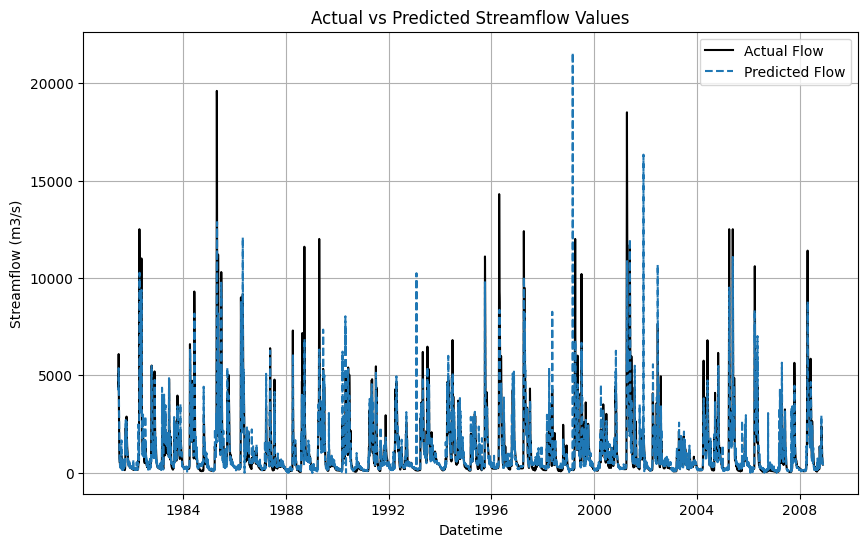

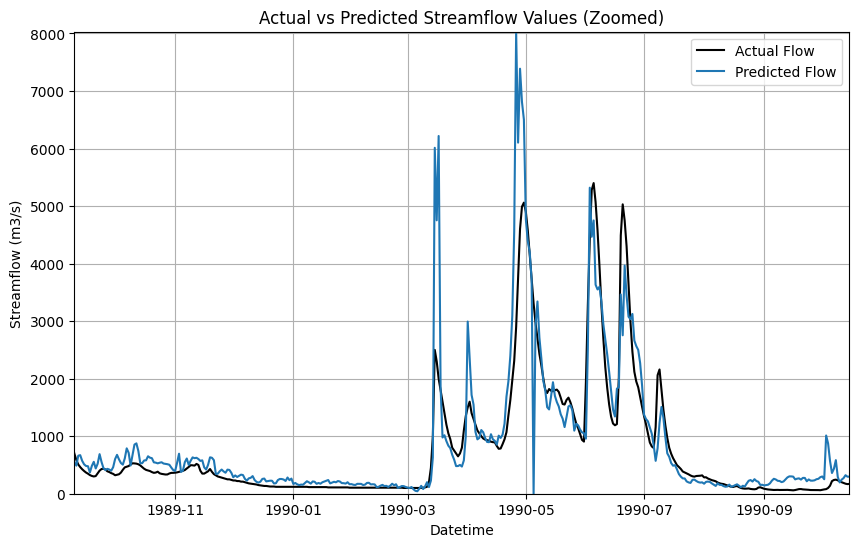

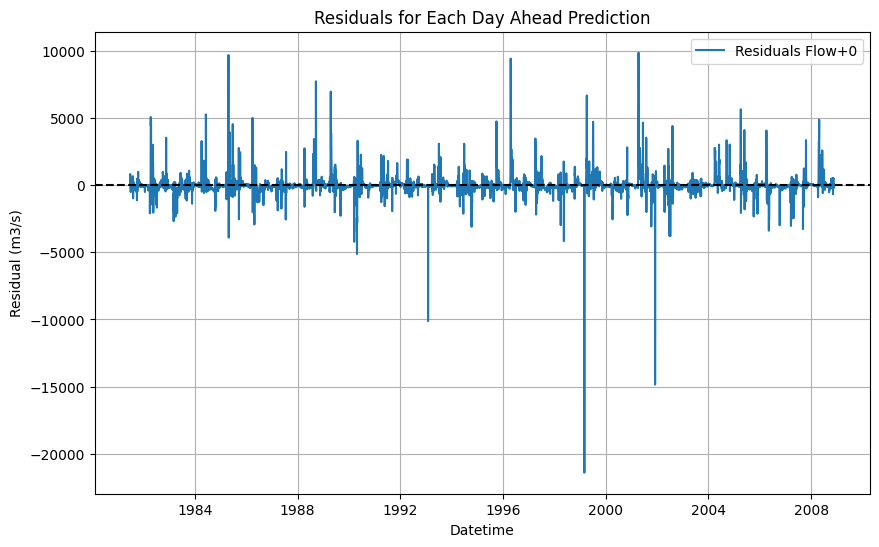

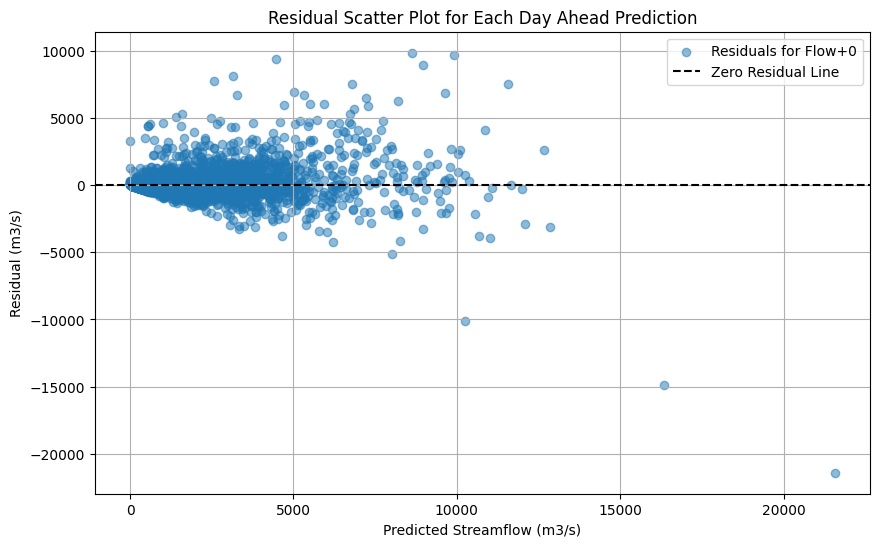

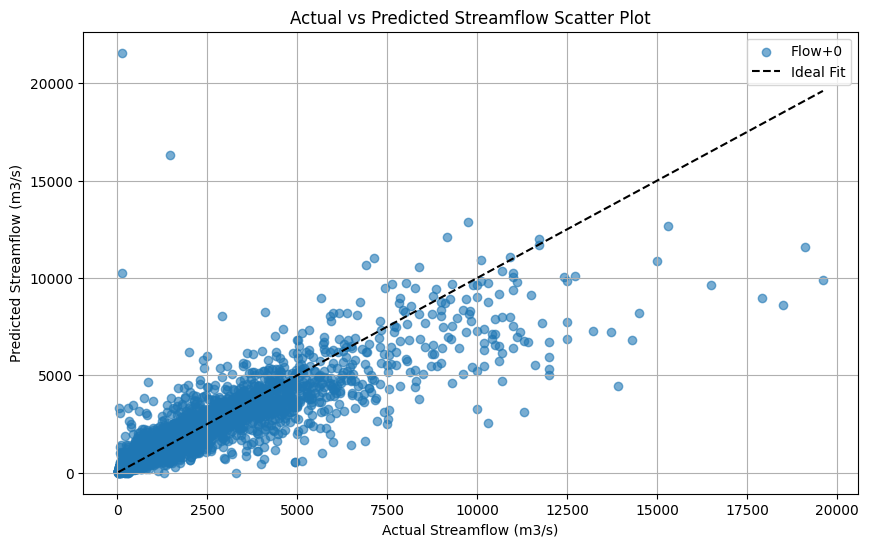

Layer 1: dense
  Weights shape: (34, 32)
  Weights: [[-8.39256719e-02 -9.39363986e-02 -6.46585897e-02 ...  5.00170253e-02
  -5.10784537e-02 -3.57212897e-34]
 [-6.78895321e-03  3.43905538e-02 -1.42641775e-02 ...  9.24063381e-03
  -1.32218618e-02  1.91113020e-34]
 [ 2.52946857e-02 -3.06840111e-02 -5.66419736e-02 ...  5.63106984e-02
  -7.09264502e-02  4.08374716e-35]
 ...
 [ 5.76143898e-03  2.87442356e-02 -1.47185172e-03 ... -2.42768135e-02
  -9.46149696e-03 -1.70761194e-34]
 [ 1.59705691e-02  2.52207890e-02  6.86210534e-03 ... -1.45363780e-02
   6.25541341e-03 -4.42223684e-34]
 [-8.27970821e-03  2.38601509e-02 -3.95101914e-03 ... -2.15465259e-02
  -1.15110716e-02  1.63715047e-34]]
  Biases shape: (32,)
  Biases: [ 0.07951681  0.37754792  0.3961431   0.17103964  0.0415134   0.16052495
 -0.26166564 -0.42484578  0.37856078  0.159135   -0.26325467 -0.2677423
  0.3563978  -0.06678894 -0.00302563 -0.05258543 -0.3632326   0.38209322
  0.21019082 -0.10577443  0.42465675  0.30187604 -0.29254976  

In [11]:
visualization(datetime3, y_pred2, y_test2, 3000, 3400)
print_model_weights_and_biases(model)